In [1]:
import algos.net2 as nn

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


data = load_digits()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_train = np.eye(10)[y_train.astype(int)]  # Convert to one-hot
y_test = np.eye(10)[y_test.astype(int)]

input_size = X.shape[1]
output_size = len(np.unique(y))

print(f"Input size: {input_size}, Output size: {output_size}")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Input size: 64, Output size: 10
Training samples: 1437, Test samples: 360


In [2]:
layers = [
    nn.FullyConnected(input_size,128),
    nn.ReLU(),
    nn.FullyConnected(128, 64),
    nn.ReLU(),
    nn.FullyConnected(64, output_size),
]

X_train = X_train.reshape(X_train.shape[0], 1, 8*8)
X_train /= 255
X_test = X_test.reshape(X_test.shape[0], 1, 8*8)
X_test /= 255

net = nn.NeuralNet(layers=layers)

net.fit(X_train, y_train, epochs=50, eta=0.01)

Epoch 1/50, Loss: 3.5982
Epoch 2/50, Loss: 2.2711
Epoch 3/50, Loss: 1.6814
Epoch 4/50, Loss: 1.3751
Epoch 5/50, Loss: 1.2036
Epoch 6/50, Loss: 1.1024
Epoch 7/50, Loss: 1.0404
Epoch 8/50, Loss: 1.0011
Epoch 9/50, Loss: 0.9753
Epoch 10/50, Loss: 0.9577
Epoch 11/50, Loss: 0.9451
Epoch 12/50, Loss: 0.9359
Epoch 13/50, Loss: 0.9290
Epoch 14/50, Loss: 0.9237
Epoch 15/50, Loss: 0.9195
Epoch 16/50, Loss: 0.9162
Epoch 17/50, Loss: 0.9134
Epoch 18/50, Loss: 0.9111
Epoch 19/50, Loss: 0.9090
Epoch 20/50, Loss: 0.9073
Epoch 21/50, Loss: 0.9056
Epoch 22/50, Loss: 0.9042
Epoch 23/50, Loss: 0.9028
Epoch 24/50, Loss: 0.9016
Epoch 25/50, Loss: 0.9004
Epoch 26/50, Loss: 0.8993
Epoch 27/50, Loss: 0.8983
Epoch 28/50, Loss: 0.8974
Epoch 29/50, Loss: 0.8965
Epoch 30/50, Loss: 0.8958
Epoch 31/50, Loss: 0.8951
Epoch 32/50, Loss: 0.8944
Epoch 33/50, Loss: 0.8938
Epoch 34/50, Loss: 0.8932
Epoch 35/50, Loss: 0.8927
Epoch 36/50, Loss: 0.8922
Epoch 37/50, Loss: 0.8917
Epoch 38/50, Loss: 0.8913
Epoch 39/50, Loss: 0.

In [3]:
out = net(X_test)
cm = np.zeros((10,10), dtype="uint32")
for i in range(len(y_test)):
    cm[np.argmax(y_test[i]),np.argmax(out[i])] += 1

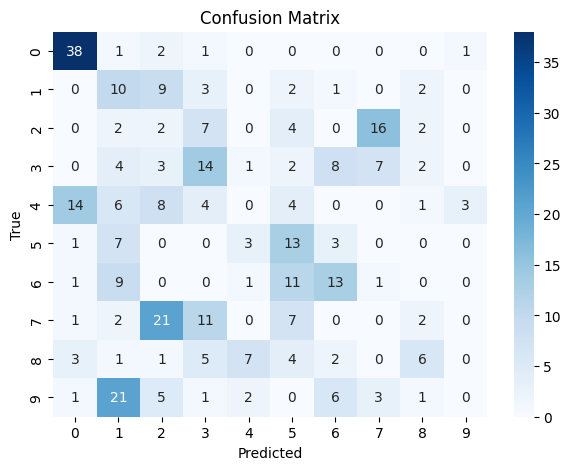

accuracy = 0.267


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print("accuracy = %0.3f" % (np.diag(cm).sum() / cm.sum(),))


In [ ]:
stronger_net = nn.NeuralNet(layers=[
    nn.FullyConnected(input_size,256),
    nn.ReLU(),
    nn.FullyConnected(256,128),
    nn.ReLU(),
    nn.FullyConnected(128,64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.FullyConnected(64,10),
    nn.Softmax(),
])

stronger_net.fit(X_train, y_train, epochs=500, eta=0.1)

Epoch 1/500, Loss: 1.5157
Epoch 2/500, Loss: 1.0313
Epoch 3/500, Loss: 0.9731
Epoch 4/500, Loss: 0.9644
Epoch 5/500, Loss: 0.9518
Epoch 6/500, Loss: 0.9483
Epoch 7/500, Loss: 0.9324
Epoch 8/500, Loss: 0.9289
Epoch 9/500, Loss: 0.9220
Epoch 10/500, Loss: 0.9190
Epoch 11/500, Loss: 0.9146
Epoch 12/500, Loss: 0.9081
Epoch 13/500, Loss: 0.9078
Epoch 14/500, Loss: 0.9033
Epoch 15/500, Loss: 0.9059
Epoch 16/500, Loss: 0.8985
Epoch 17/500, Loss: 0.8983
Epoch 18/500, Loss: 0.8943
Epoch 19/500, Loss: 0.8949
Epoch 20/500, Loss: 0.8871
Epoch 21/500, Loss: 0.8883
Epoch 22/500, Loss: 0.8859
Epoch 23/500, Loss: 0.8812
Epoch 24/500, Loss: 0.8813
Epoch 25/500, Loss: 0.8815
Epoch 26/500, Loss: 0.8805
Epoch 27/500, Loss: 0.8779
Epoch 28/500, Loss: 0.8778
Epoch 29/500, Loss: 0.8758
Epoch 30/500, Loss: 0.8740
Epoch 31/500, Loss: 0.8723
Epoch 32/500, Loss: 0.8734
Epoch 33/500, Loss: 0.8699
Epoch 34/500, Loss: 0.8700
Epoch 35/500, Loss: 0.8641
Epoch 36/500, Loss: 0.8657
Epoch 37/500, Loss: 0.8648
Epoch 38/5

Text(58.222222222222214, 0.5, 'True')

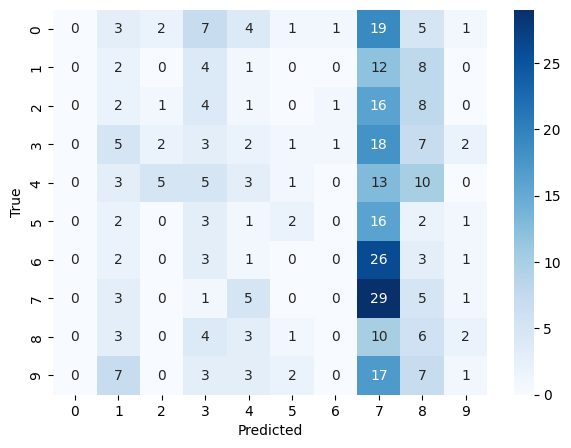

In [ ]:
out = stronger_net(X_test)
cm = np.zeros((10,10), dtype="uint32")
for i in range(len(y_test)):
    cm[np.argmax(y_test[i]),np.argmax(out[i])] += 1
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print("accuracy = %0.3f" % (np.diag(cm).sum() / cm.sum(),))